In [29]:
pip install pandas numpy matplotlib scipy python-docx

In [30]:
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import warnings

In [31]:
warnings.filterwarnings("ignore")

In [8]:
file_path = "cleaned_agri_crop_yield_dataset.csv"

df = pd.read_csv(file_path)

print("=" * 60)
print("AGRICULTURAL CROP YIELD DATASET - EDA")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

AGRICULTURAL CROP YIELD DATASET - EDA

Dataset Shape:
(1200, 15)

First 5 Rows:
        Crop  Crop_Year  Season           State      Area   Production  \
0     Millet       2020  Kharif    Chhattisgarh  15076.50   17031.9123   
1  Sugarcane       2001    Rabi  Madhya Pradesh   6047.07  145774.8398   
2     Barley       2015  Kharif    Chhattisgarh   4505.96   10996.0146   
3    Soybean       1999  Kharif  Andhra Pradesh    741.30     749.3950   
4     Cotton       2014  Kharif  Madhya Pradesh   2604.43    3865.8288   

   Annual_Rainfall    Fertilizer   Pesticide   Yield  Area_Normalized  \
0            987.8  2.188493e+06  75230.8098  1.1297           0.3694   
1           1760.6  3.185354e+05  47011.8808  6.8491           0.1451   
2           1294.2  3.318065e+05   8451.0804  2.4403           0.1068   
3            300.0  9.602865e+04   1146.2010  1.0109           0.0133   
4            414.5  2.846358e+05  16639.2337  1.4843           0.0596   

   Annual_Rainfall_Normalized  Ferti

In [10]:
print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe(include="all"))


DATASET INFORMATION

Data Types:
Crop                           object
Crop_Year                       int64
Season                         object
State                          object
Area                          float64
Production                    float64
Annual_Rainfall               float64
Fertilizer                    float64
Pesticide                     float64
Yield                         float64
Area_Normalized               float64
Annual_Rainfall_Normalized    float64
Fertilizer_Normalized         float64
Pesticide_Normalized          float64
Yield_Normalized              float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Crop                        1200 non-null   object 
 1   Crop_Year                   1200 non-null   int64  
 2   Season              

In [11]:
print("\n" + "=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_values = df.isnull().sum()

print("\nMissing Values:")
print(missing_values)

total_missing = missing_values.sum()

print("\nTotal Missing Values:", total_missing)

# Create missing-value graph
if total_missing > 0:

    missing = missing_values[missing_values > 0]

    plt.figure(figsize=(10, 6))
    plt.bar(missing.index, missing.values)
    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig("missing_values.png", dpi=300)
    plt.show()

else:

    print("No missing values found.")


MISSING VALUE ANALYSIS

Missing Values:
Crop                          0
Crop_Year                     0
Season                        0
State                         0
Area                          0
Production                    0
Annual_Rainfall               0
Fertilizer                    0
Pesticide                     0
Yield                         0
Area_Normalized               0
Annual_Rainfall_Normalized    0
Fertilizer_Normalized         0
Pesticide_Normalized          0
Yield_Normalized              0
dtype: int64

Total Missing Values: 0
No missing values found.


In [12]:
print("\n" + "=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


DUPLICATE ANALYSIS
Number of duplicate rows: 0


In [13]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)


Numerical Columns:
['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Area_Normalized', 'Annual_Rainfall_Normalized', 'Fertilizer_Normalized', 'Pesticide_Normalized', 'Yield_Normalized']

Categorical Columns:
['Crop', 'Season', 'State']


In [14]:
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

if len(numeric_columns) > 0:

    descriptive_statistics = df[numeric_columns].describe().T

    descriptive_statistics["median"] = df[
        numeric_columns
    ].median()

    descriptive_statistics["skewness"] = df[
        numeric_columns
    ].skew()

    descriptive_statistics["kurtosis"] = df[
        numeric_columns
    ].kurtosis()

    print(descriptive_statistics)


DESCRIPTIVE STATISTICS
                             count          mean           std         min  \
Crop_Year                   1200.0  2.008535e+03  7.107334e+00   1997.0000   
Area                        1200.0  1.296555e+04  1.256141e+04    205.3100   
Production                  1200.0  4.335723e+04  5.006618e+04    338.4539   
Annual_Rainfall             1200.0  1.057557e+03  4.296356e+02    300.0000   
Fertilizer                  1200.0  1.474070e+06  1.477408e+06  10775.7143   
Pesticide                   1200.0  5.050156e+04  5.252219e+04    356.0728   
Yield                       1200.0  2.789574e+00  2.042215e+00      0.4880   
Area_Normalized             1200.0  3.169435e-01  3.120042e-01      0.0000   
Annual_Rainfall_Normalized  1200.0  3.768322e-01  2.137141e-01      0.0000   
Fertilizer_Normalized       1200.0  3.134697e-01  3.164935e-01      0.0000   
Pesticide_Normalized        1200.0  3.067698e-01  3.213089e-01      0.0000   
Yield_Normalized            1200.0  3.61


Generating numerical distribution graphs...


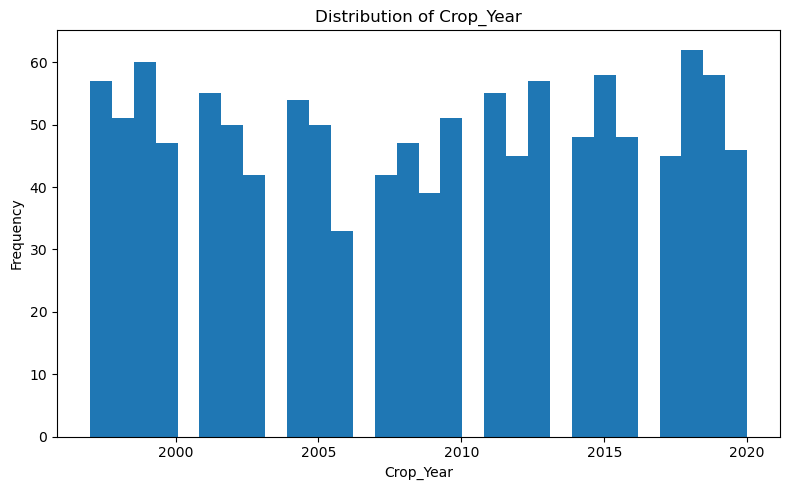

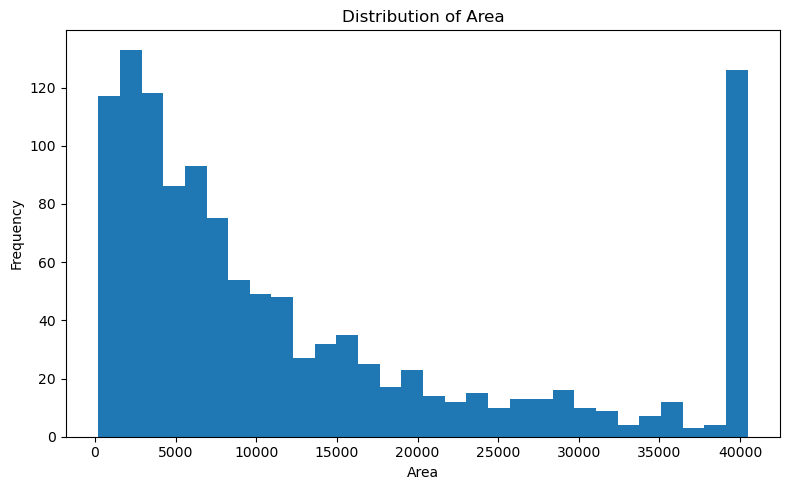

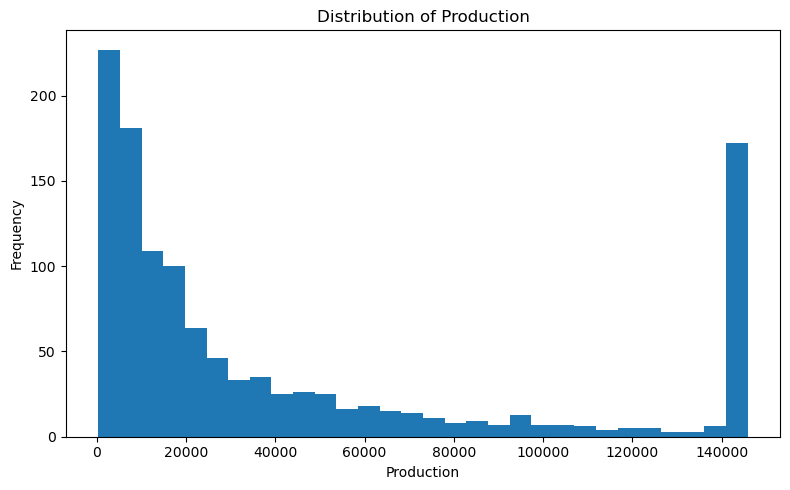

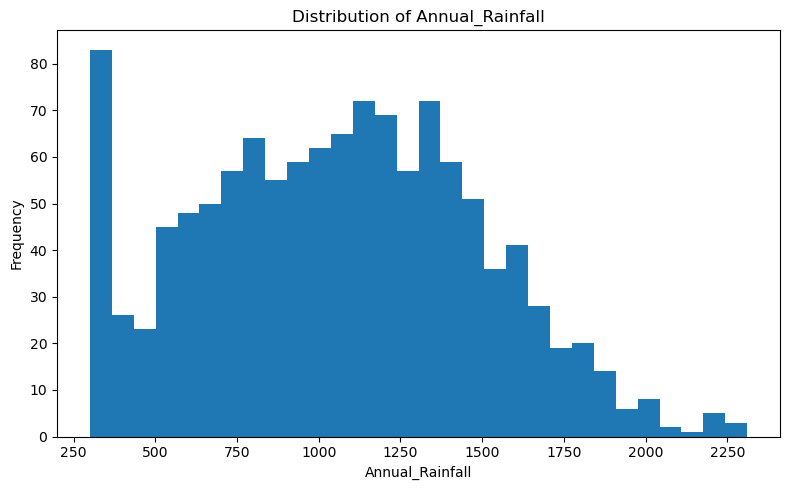

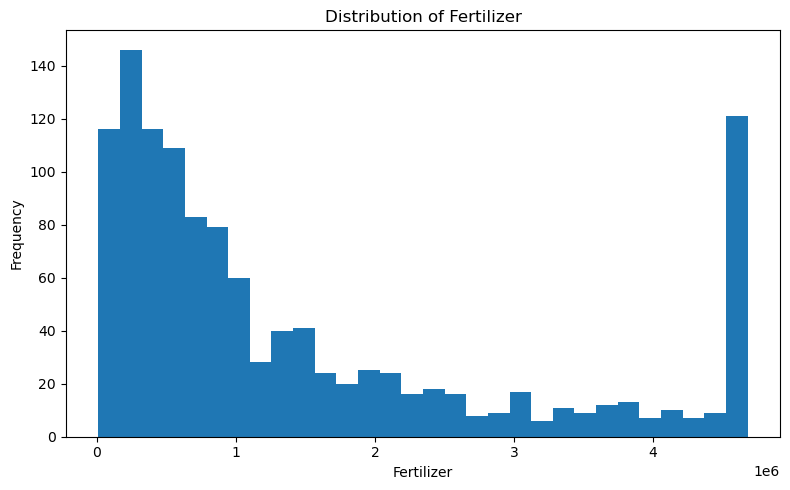

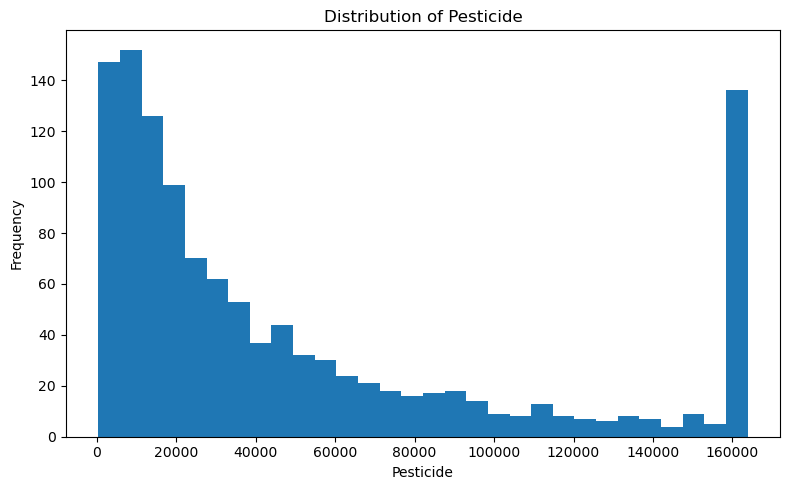

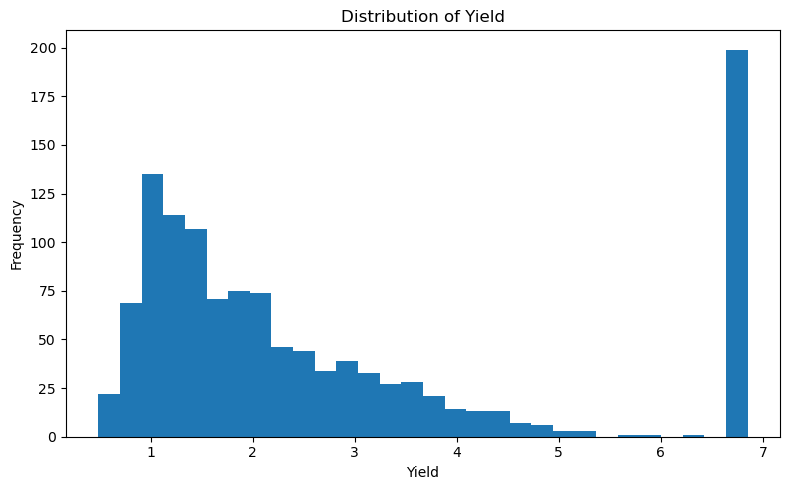

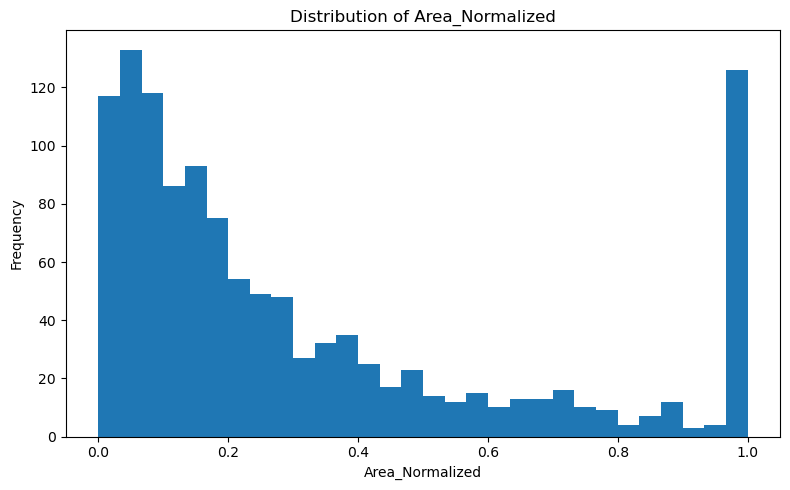

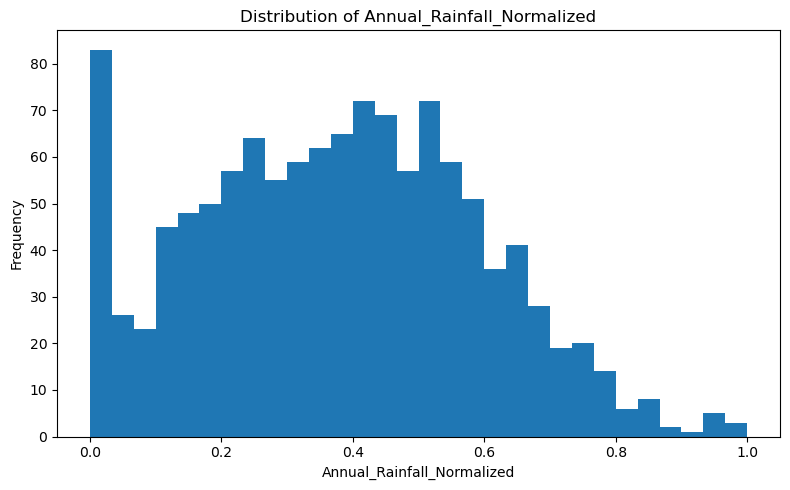

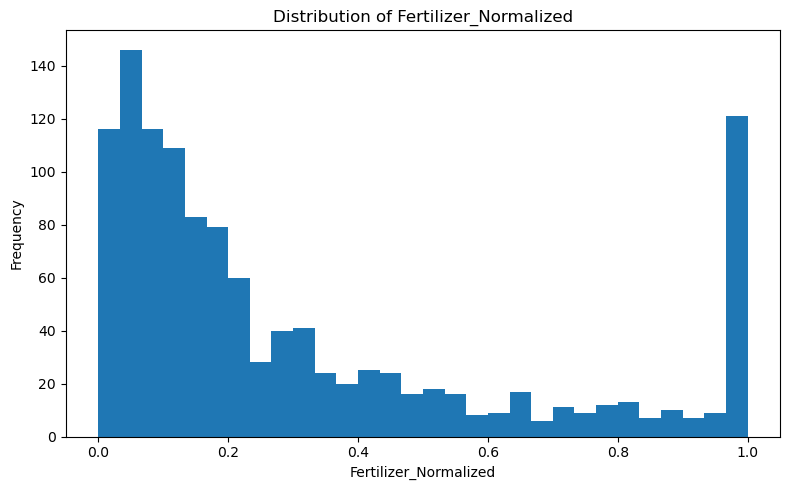

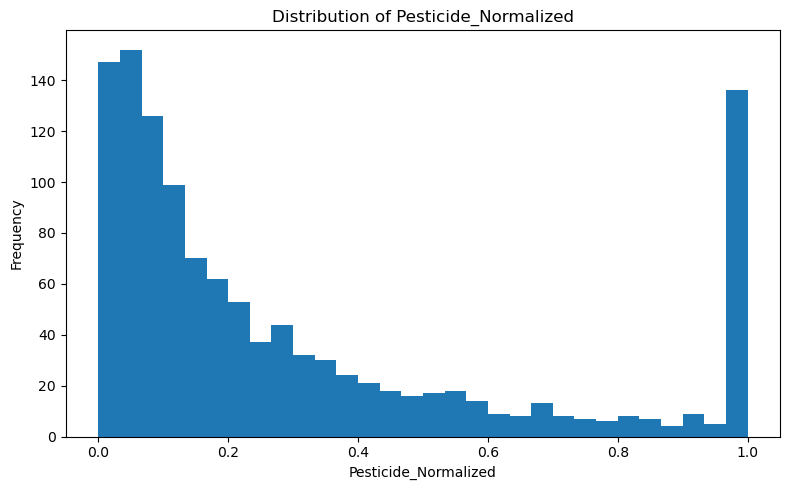

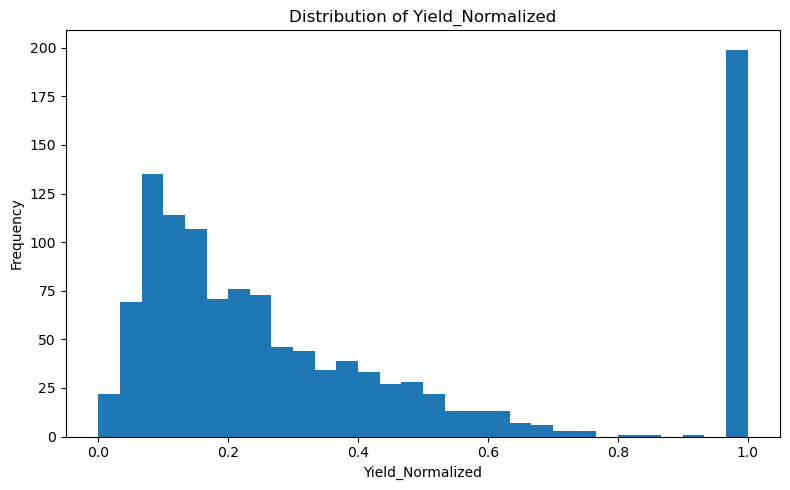

In [15]:
print("\nGenerating numerical distribution graphs...")

distribution_files = []

for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[column].dropna(),
        bins=30
    )

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()

    filename = "distribution_" + column.replace(" ", "_") + ".png"

    plt.savefig(
        filename,
        dpi=300
    )

    plt.show()

    distribution_files.append(
        (column, filename)
    )


Generating boxplots...


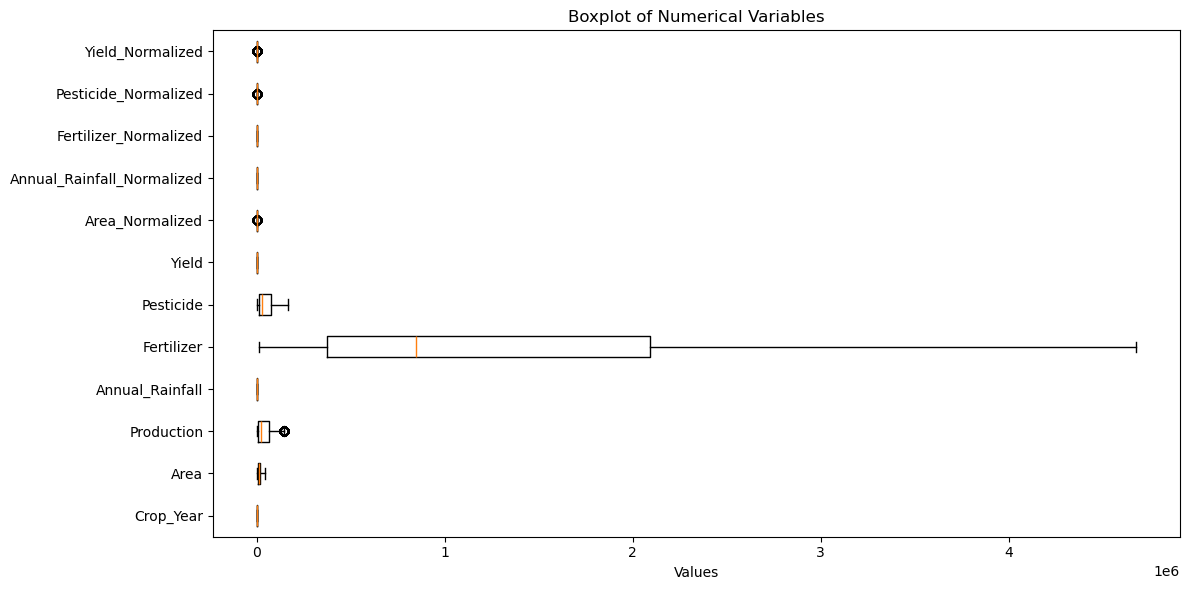

In [16]:
print("\nGenerating boxplots...")

if len(numeric_columns) > 0:

    plt.figure(
        figsize=(
            12,
            max(6, len(numeric_columns) * 0.5)
        )
    )

    plt.boxplot(
        [
            df[column].dropna()
            for column in numeric_columns
        ],
        tick_labels=numeric_columns,
        vert=False
    )

    plt.title(
        "Boxplot of Numerical Variables"
    )

    plt.xlabel("Values")

    plt.tight_layout()

    plt.savefig(
        "boxplot_numeric_variables.png",
        dpi=300
    )

    plt.show()

In [17]:
print("\n" + "=" * 60)
print("OUTLIER ANALYSIS USING IQR")
print("=" * 60)

outlier_results = []

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    number_of_outliers = len(outliers)

    percentage = (
        number_of_outliers /
        len(df)
    ) * 100

    outlier_results.append(
        {
            "Column": column,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Limit": lower_limit,
            "Upper Limit": upper_limit,
            "Outliers": number_of_outliers,
            "Percentage": percentage
        }
    )

outlier_df = pd.DataFrame(
    outlier_results
)

print(outlier_df)

outlier_df.to_csv(
    "outlier_analysis.csv",
    index=False
)


OUTLIER ANALYSIS USING IQR
                        Column             Q1            Q3           IQR  \
0                    Crop_Year    2002.000000  2.015000e+03  1.300000e+01   
1                         Area    3484.537500  1.827699e+04  1.479245e+04   
2                   Production    6742.538850  6.235546e+04  5.561292e+04   
3              Annual_Rainfall     733.825000  1.364425e+03  6.306000e+02   
4                   Fertilizer  370352.090675  2.093746e+06  1.723394e+06   
5                    Pesticide   11382.524650  7.235726e+04  6.097473e+04   
6                        Yield       1.274525  3.504400e+00  2.229875e+00   
7              Area_Normalized       0.081475  4.488500e-01  3.673750e-01   
8   Annual_Rainfall_Normalized       0.215775  5.295000e-01  3.137250e-01   
9        Fertilizer_Normalized       0.077000  4.462000e-01  3.692000e-01   
10        Pesticide_Normalized       0.067450  4.404500e-01  3.730000e-01   
11            Yield_Normalized       0.123675  4


Category: Crop
Crop
Millet        117
Wheat         117
Soybean       110
Potato        103
Barley        102
Cotton        101
Maize          98
Pigeon Pea     95
Groundnut      94
Chickpea       92
Sugarcane      91
Rice           80
Name: count, dtype: int64


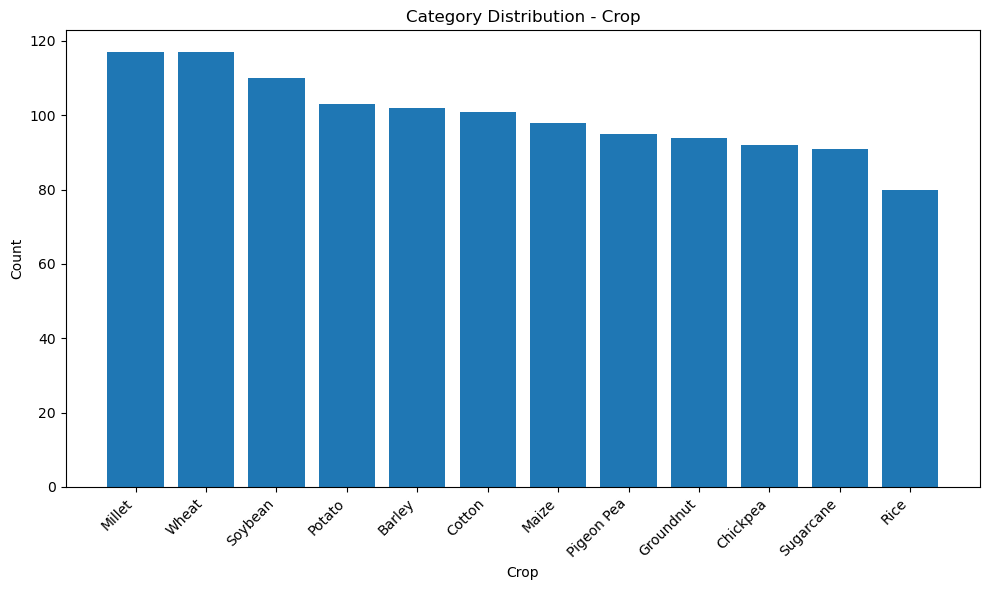


Category: Season
Season
Whole Year    315
Summer        310
Kharif        295
Rabi          280
Name: count, dtype: int64


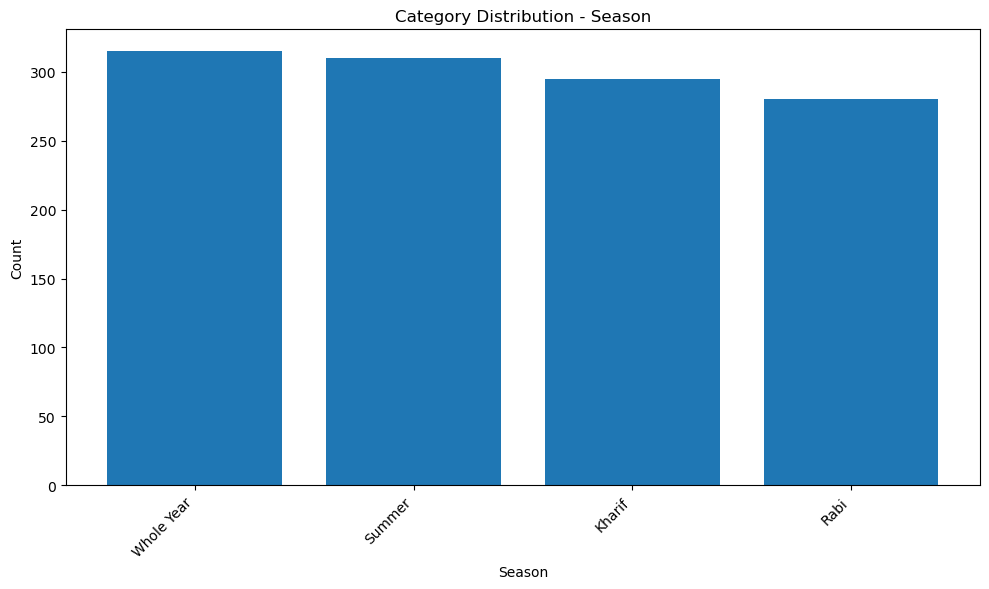


Category: State
State
Madhya Pradesh    90
Odisha            87
Maharashtra       85
Gujarat           85
West Bengal       84
Bihar             81
Tamil Nadu        80
Rajasthan         78
Punjab            73
Andhra Pradesh    70
Telangana         70
Uttar Pradesh     67
Haryana           66
Chhattisgarh      66
Karnataka         61
Assam             57
Name: count, dtype: int64


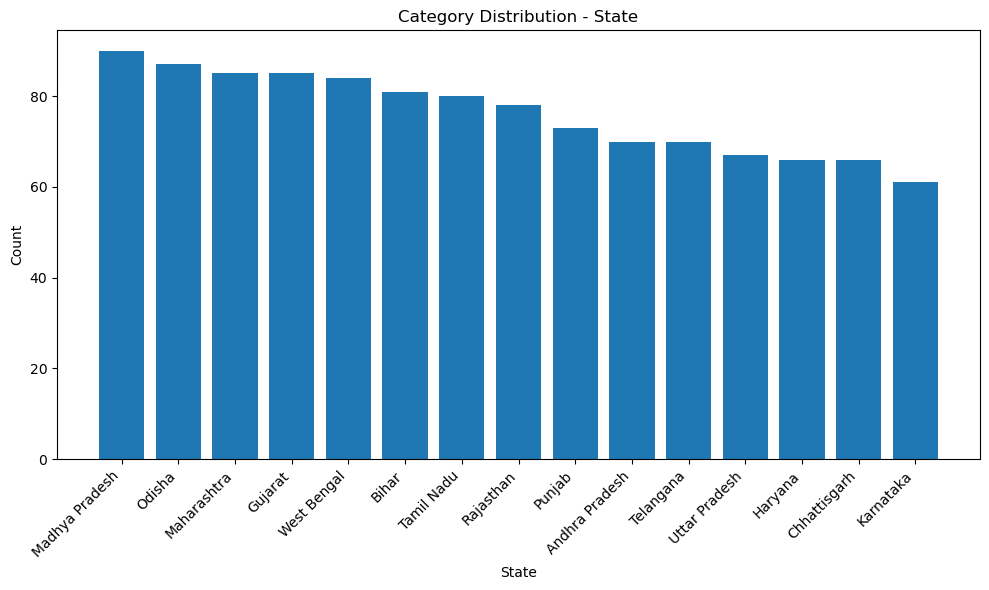

In [18]:
categorical_files = []

for column in categorical_columns:

    print("\nCategory:", column)

    print(
        df[column].value_counts()
    )

    value_counts = (
        df[column]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(10, 6))

    plt.bar(
        value_counts.index.astype(str),
        value_counts.values
    )

    plt.title(
        "Category Distribution - " +
        column
    )

    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    filename = (
        "categorical_"
        + column.replace(" ", "_")
        + ".png"
    )

    plt.savefig(
        filename,
        dpi=300
    )

    plt.show()

    categorical_files.append(
        (column, filename)
    )


CORRELATION ANALYSIS
                            Crop_Year      Area  Production  Annual_Rainfall  \
Crop_Year                    1.000000 -0.000297   -0.040649         0.008568   
Area                        -0.000297  1.000000    0.569460         0.036358   
Production                  -0.040649  0.569460    1.000000         0.054541   
Annual_Rainfall              0.008568  0.036358    0.054541         1.000000   
Fertilizer                   0.006333  0.946758    0.535113         0.033005   
Pesticide                    0.009179  0.854678    0.503386         0.045885   
Yield                       -0.040868 -0.038925    0.675979         0.048810   
Area_Normalized             -0.000296  1.000000    0.569464         0.036357   
Annual_Rainfall_Normalized   0.008572  0.036352    0.054542         1.000000   
Fertilizer_Normalized        0.006335  0.946757    0.535112         0.033006   
Pesticide_Normalized         0.009177  0.854679    0.503385         0.045882   
Yield_Normalized  

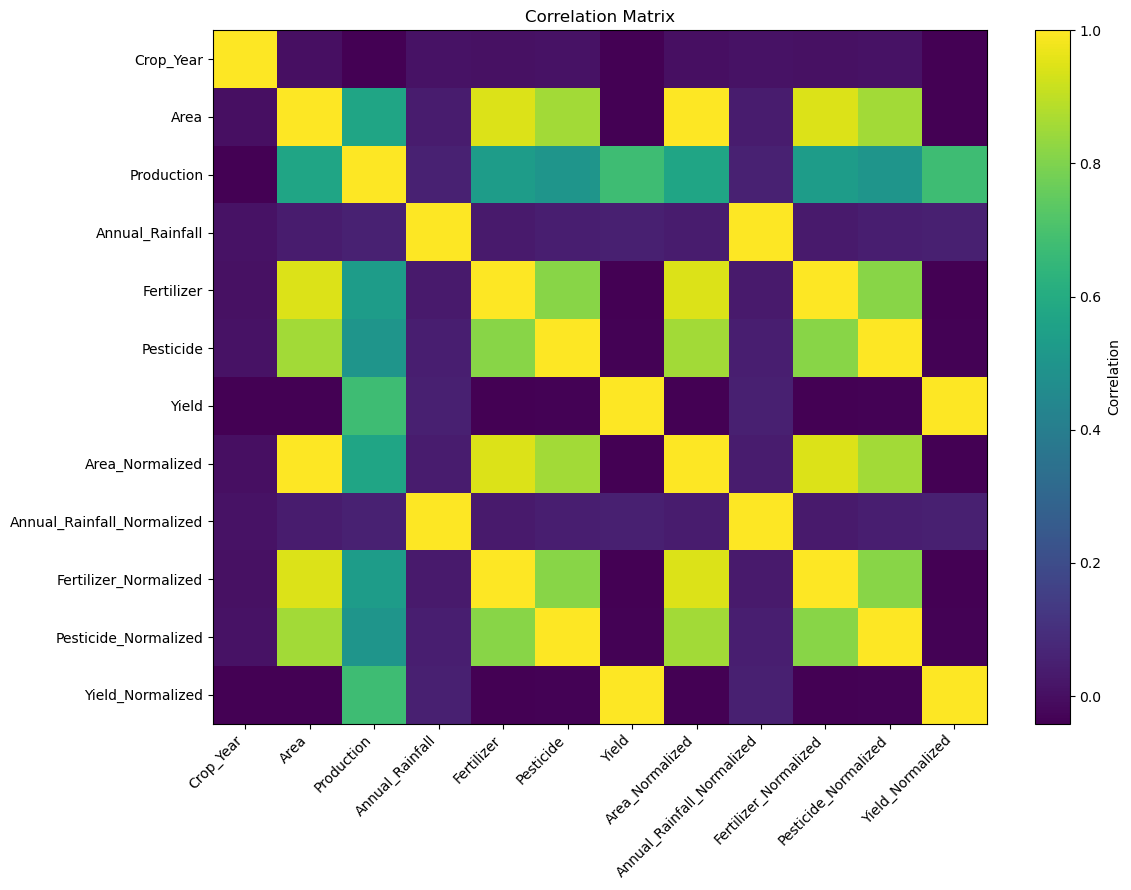

In [19]:
print("\n" + "=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

if len(numeric_columns) >= 2:

    correlation_matrix = df[
        numeric_columns
    ].corr()

    print(
        correlation_matrix
    )

    # Correlation heatmap
    plt.figure(
        figsize=(12, 9)
    )

    plt.imshow(
        correlation_matrix,
        aspect="auto"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(len(numeric_columns)),
        numeric_columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(numeric_columns)),
        numeric_columns
    )

    plt.title(
        "Correlation Matrix"
    )

    plt.tight_layout()

    plt.savefig(
        "correlation_matrix.png",
        dpi=300
    )

    plt.show()

In [20]:
print("\n" + "=" * 60)
print("STRONGEST CORRELATIONS")
print("=" * 60)

correlation_pairs = []

if len(numeric_columns) >= 2:

    for i in range(
        len(numeric_columns)
    ):

        for j in range(
            i + 1,
            len(numeric_columns)
        ):

            column1 = numeric_columns[i]
            column2 = numeric_columns[j]

            correlation = (
                df[column1]
                .corr(df[column2])
            )

            correlation_pairs.append(
                (
                    column1,
                    column2,
                    correlation
                )
            )

correlation_pairs = sorted(
    correlation_pairs,
    key=lambda x: abs(x[2]),
    reverse=True
)

for pair in correlation_pairs[:10]:

    print(
        pair[0],
        "<->",
        pair[1],
        ":",
        round(pair[2], 4)
    )


STRONGEST CORRELATIONS
Yield <-> Yield_Normalized : 1.0
Pesticide <-> Pesticide_Normalized : 1.0
Fertilizer <-> Fertilizer_Normalized : 1.0
Area <-> Area_Normalized : 1.0
Annual_Rainfall <-> Annual_Rainfall_Normalized : 1.0
Area <-> Fertilizer : 0.9468
Fertilizer <-> Area_Normalized : 0.9468
Area <-> Fertilizer_Normalized : 0.9468
Area_Normalized <-> Fertilizer_Normalized : 0.9468
Area <-> Pesticide_Normalized : 0.8547


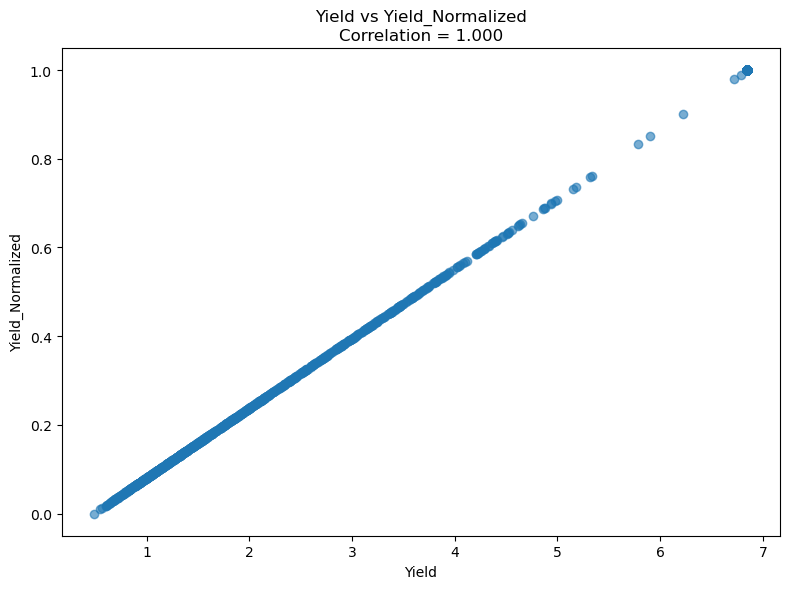

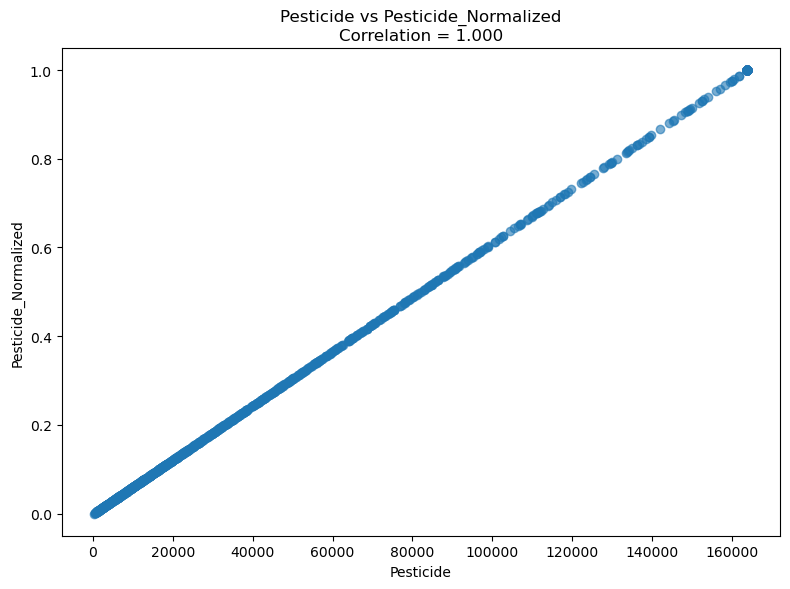

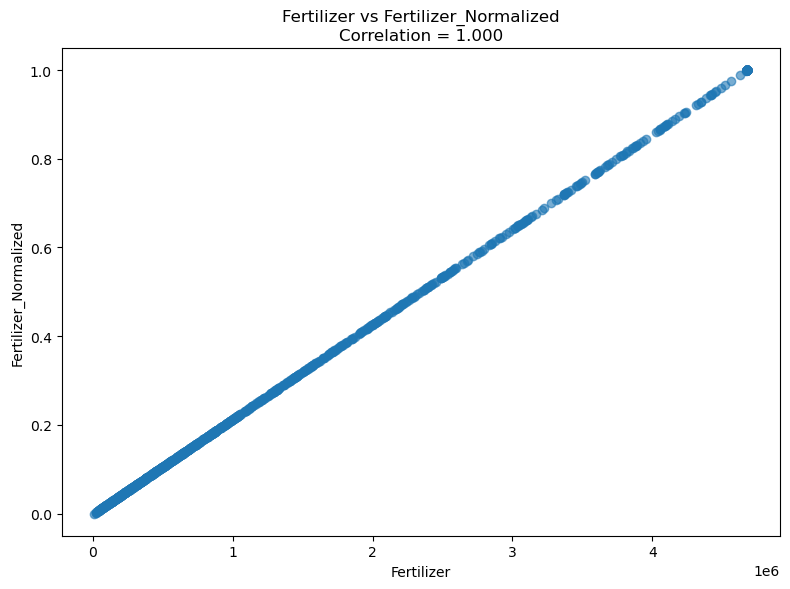

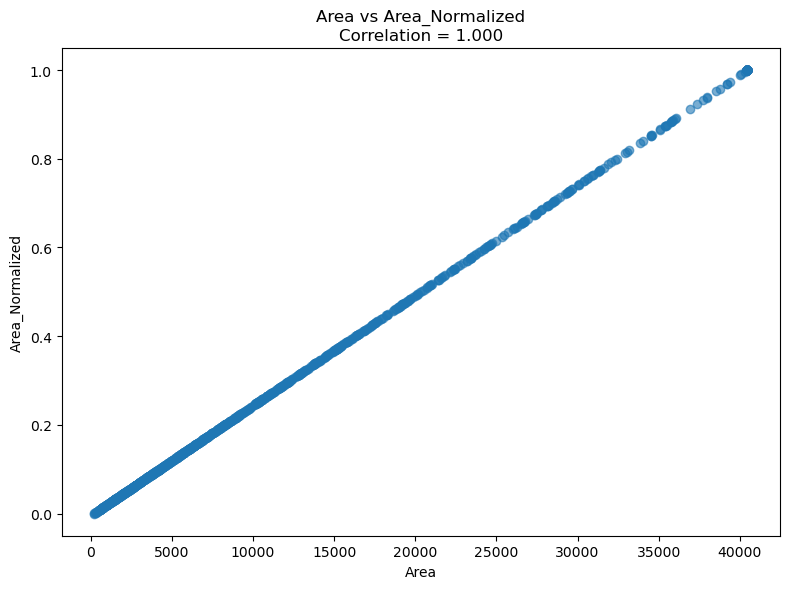

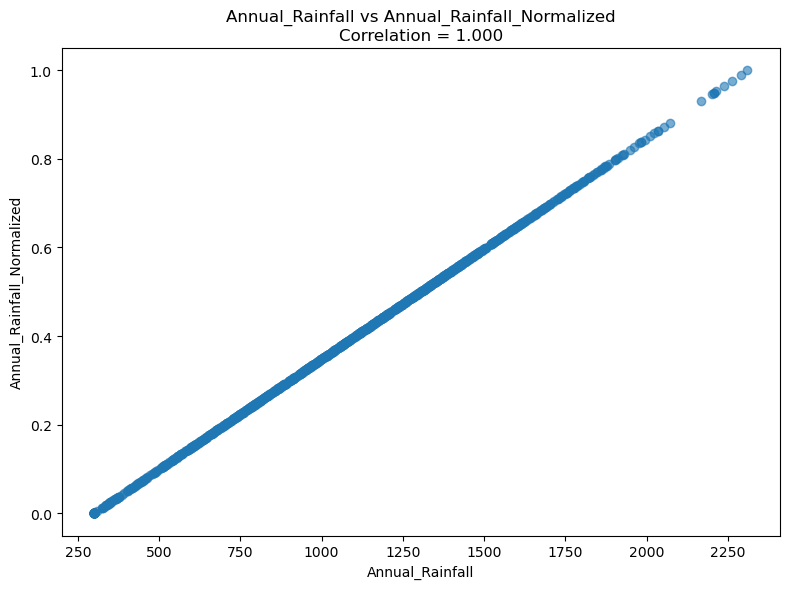

In [21]:
scatter_files = []

for index, pair in enumerate(
    correlation_pairs[:5]
):

    column1 = pair[0]
    column2 = pair[1]
    correlation = pair[2]

    plt.figure(
        figsize=(8, 6)
    )

    plt.scatter(
        df[column1],
        df[column2],
        alpha=0.6
    )

    plt.xlabel(column1)
    plt.ylabel(column2)

    plt.title(
        f"{column1} vs {column2}\n"
        f"Correlation = {correlation:.3f}"
    )

    plt.tight_layout()

    filename = (
        f"scatter_{index + 1}.png"
    )

    plt.savefig(
        filename,
        dpi=300
    )

    plt.show()

    scatter_files.append(
        (
            column1,
            column2,
            filename,
            correlation
        )
    )

In [22]:
yield_columns = [
    column
    for column in df.columns
    if "yield" in column.lower()
]

print("\nPossible Yield Columns:")
print(yield_columns)

if len(yield_columns) > 0:

    yield_column = yield_columns[0]

else:

    yield_column = None


Possible Yield Columns:
['Yield', 'Yield_Normalized']



CROP YIELD ANALYSIS
Yield Column: Yield

Yield Statistics:
count    1200.000000
mean        2.789574
std         2.042215
min         0.488000
25%         1.274525
50%         1.983900
75%         3.504400
max         6.849100
Name: Yield, dtype: float64


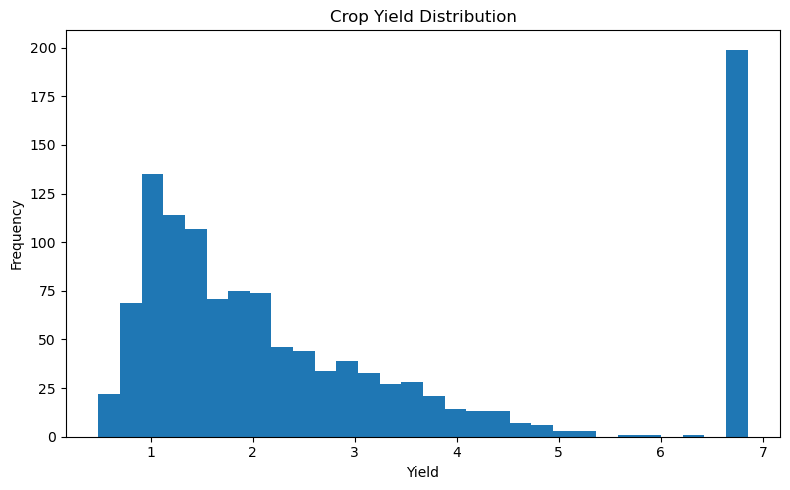

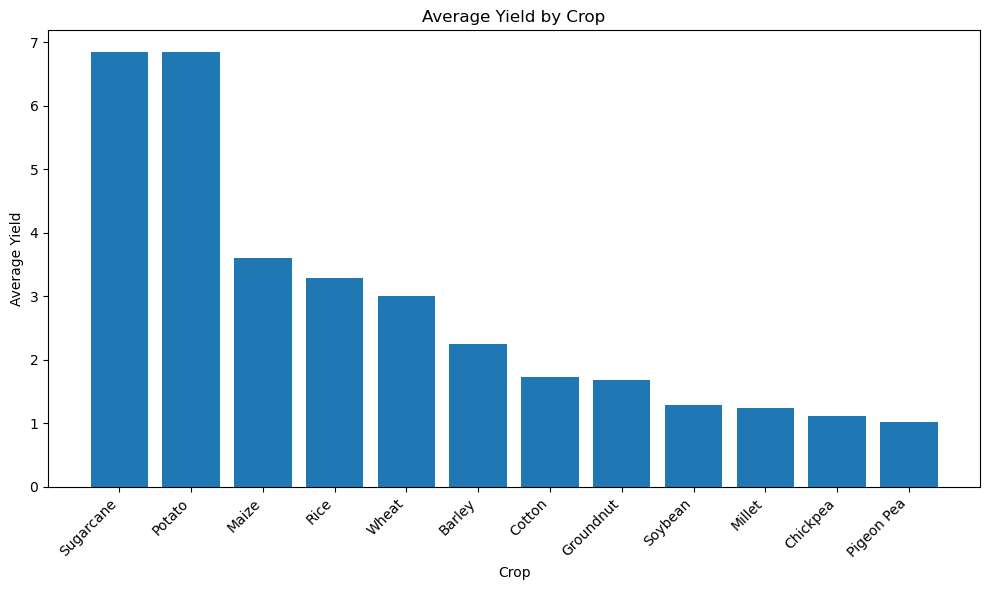

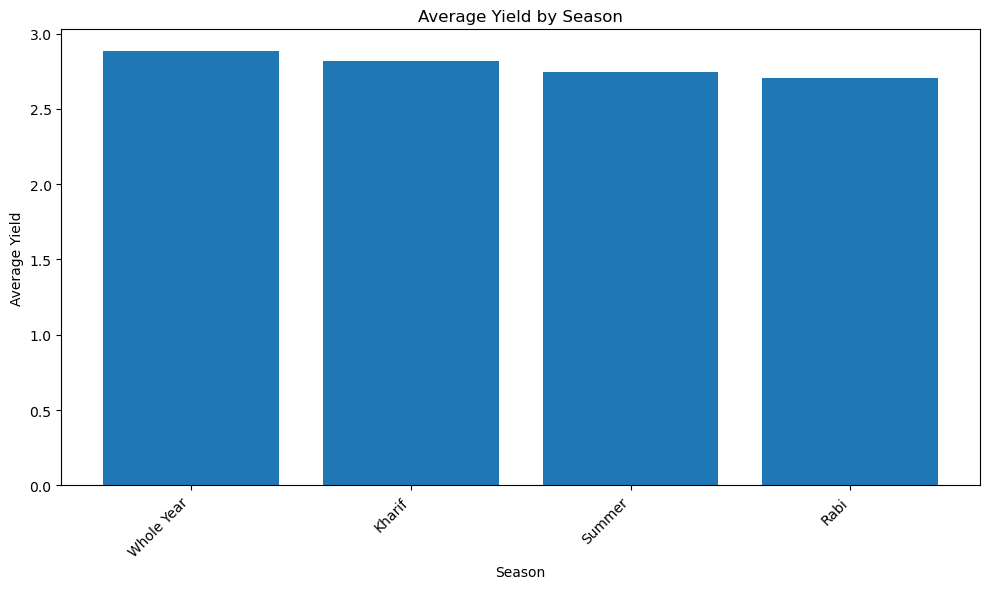

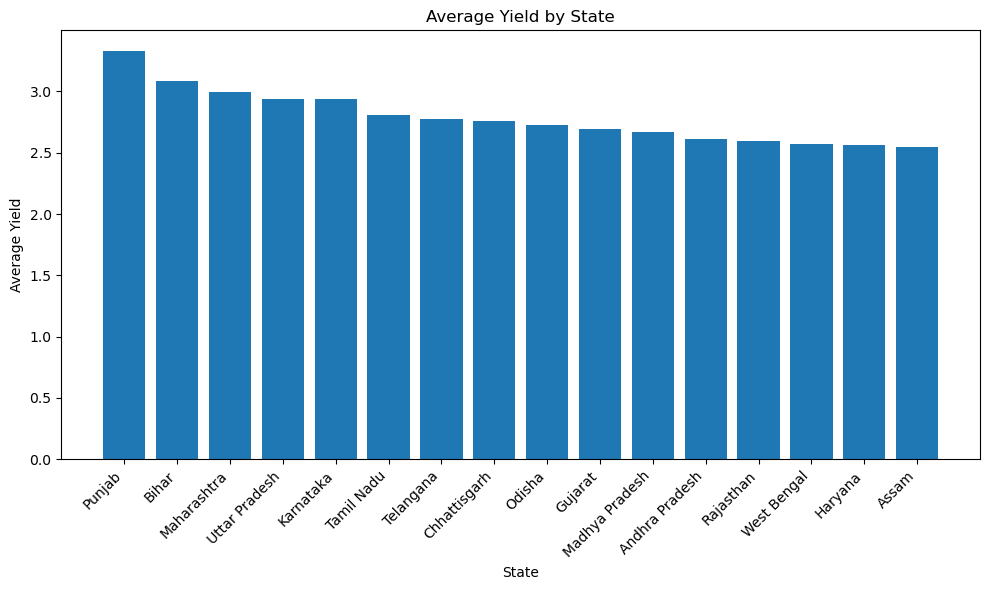

In [23]:
yield_category_files = []

if yield_column is not None:

    print("\n" + "=" * 60)
    print("CROP YIELD ANALYSIS")
    print("=" * 60)

    print(
        "Yield Column:",
        yield_column
    )

    print(
        "\nYield Statistics:"
    )

    print(
        df[yield_column].describe()
    )

    # Yield histogram

    plt.figure(
        figsize=(8, 5)
    )

    plt.hist(
        df[yield_column].dropna(),
        bins=30
    )

    plt.title(
        "Crop Yield Distribution"
    )

    plt.xlabel(
        yield_column
    )

    plt.ylabel(
        "Frequency"
    )

    plt.tight_layout()

    plt.savefig(
        "crop_yield_distribution.png",
        dpi=300
    )

    plt.show()

    # Yield by categorical columns

    for column in categorical_columns:

        if df[column].nunique() <= 30:

            yield_group = (
                df.groupby(column)[yield_column]
                .mean()
                .sort_values(
                    ascending=False
                )
            )

            plt.figure(
                figsize=(10, 6)
            )

            plt.bar(
                yield_group.index.astype(str),
                yield_group.values
            )

            plt.title(
                f"Average {yield_column} by {column}"
            )

            plt.xlabel(column)

            plt.ylabel(
                f"Average {yield_column}"
            )

            plt.xticks(
                rotation=45,
                ha="right"
            )

            plt.tight_layout()

            filename = (
                "yield_by_"
                + column.replace(
                    " ",
                    "_"
                )
                + ".png"
            )

            plt.savefig(
                filename,
                dpi=300
            )

            plt.show()

            yield_category_files.append(
                (column, filename)
            )


TIME TREND ANALYSIS
Crop_Year
1997    2.709209
1998    2.975369
1999    3.023272
2000    2.929674
2001    3.673289
2002    2.646056
2003    2.779840
2004    2.600139
2005    2.730906
2006    2.766621
2007    2.765248
2008    3.138881
2009    2.255990
2010    2.854847
2011    2.819193
2012    2.275389
2013    2.850565
2014    2.106935
2015    2.593195
2016    3.198554
2017    2.407527
2018    2.656881
2019    3.030005
2020    2.866043
Name: Yield, dtype: float64


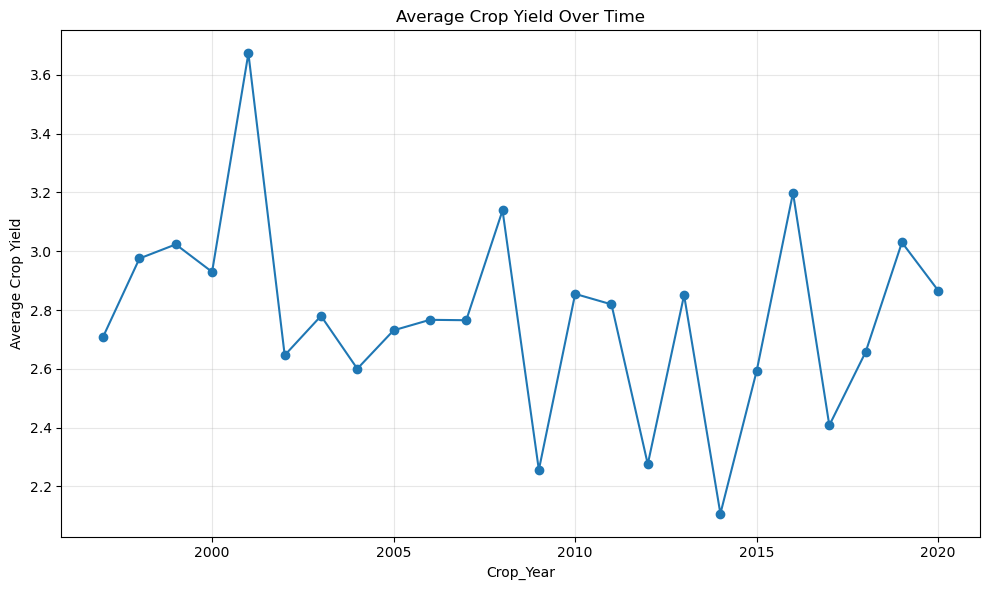

In [24]:
trend_file = None
year_column = None

for column in df.columns:

    if "year" in column.lower():

        year_column = column
        break

if (
    year_column is not None
    and yield_column is not None
):

    print("\n" + "=" * 60)
    print("TIME TREND ANALYSIS")
    print("=" * 60)

    yearly_yield = (
        df.groupby(
            year_column
        )[yield_column]
        .mean()
        .sort_index()
    )

    print(
        yearly_yield
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        yearly_yield.index,
        yearly_yield.values,
        marker="o"
    )

    plt.title(
        "Average Crop Yield Over Time"
    )

    plt.xlabel(
        year_column
    )

    plt.ylabel(
        "Average Crop Yield"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    trend_file = (
        "crop_yield_trend.png"
    )

    plt.savefig(
        trend_file,
        dpi=300
    )

    plt.show()


In [25]:
print("\n" + "=" * 60)
print("STATISTICAL ANALYSIS")
print("=" * 60)

statistical_results = []

# Normality test for numerical variables

for column in numeric_columns:

    data = df[column].dropna()

    if len(data) >= 3:

        # Shapiro is limited for very large samples
        sample = (
            data.sample(
                min(5000, len(data)),
                random_state=42
            )
        )

        statistic, p_value = stats.shapiro(
            sample
        )

        statistical_results.append(
            {
                "Variable": column,
                "Test": "Shapiro-Wilk",
                "Statistic": statistic,
                "P-Value": p_value
            }
        )

        print(
            column,
            "- p-value:",
            round(p_value, 6)
        )


STATISTICAL ANALYSIS
Crop_Year - p-value: 0.0
Area - p-value: 0.0
Production - p-value: 0.0
Annual_Rainfall - p-value: 0.0
Fertilizer - p-value: 0.0
Pesticide - p-value: 0.0
Yield - p-value: 0.0
Area_Normalized - p-value: 0.0
Annual_Rainfall_Normalized - p-value: 0.0
Fertilizer_Normalized - p-value: 0.0
Pesticide_Normalized - p-value: 0.0
Yield_Normalized - p-value: 0.0


In [26]:
insights = []

# Dataset insight

insights.append(
    f"The dataset contains {len(df):,} observations "
    f"and {len(df.columns)} variables."
)

# Missing values

if total_missing == 0:

    insights.append(
        "No missing values were detected in the dataset."
    )

else:

    insights.append(
        f"The dataset contains {total_missing:,} missing values."
    )

# Duplicate insight

if duplicates == 0:

    insights.append(
        "No duplicate records were detected."
    )

else:

    insights.append(
        f"{duplicates:,} duplicate records were detected."
    )

# Outlier insight

if len(outlier_df) > 0:

    highest_outlier = outlier_df.loc[
        outlier_df["Outliers"].idxmax()
    ]

    insights.append(
        f"The variable with the largest number of "
        f"IQR-based outliers is "
        f"{highest_outlier['Column']} with "
        f"{int(highest_outlier['Outliers'])} "
        f"observations."
    )

# Correlation insight

if len(correlation_pairs) > 0:

    strongest = correlation_pairs[0]

    insights.append(
        f"The strongest linear relationship is between "
        f"{strongest[0]} and {strongest[1]}, "
        f"with a Pearson correlation of "
        f"{strongest[2]:.3f}."
    )

# Yield insight

if yield_column is not None:

    yield_mean = df[
        yield_column
    ].mean()

    yield_median = df[
        yield_column
    ].median()

    insights.append(
        f"The average {yield_column} is "
        f"{yield_mean:.3f}, while the median is "
        f"{yield_median:.3f}."
    )

In [32]:
print("\n" + "=" * 60)
print("CREATING WORD REPORT")
print("=" * 60)

document = Document()

# Page margins

for section in document.sections:

    section.top_margin = Inches(0.7)
    section.bottom_margin = Inches(0.7)
    section.left_margin = Inches(0.7)
    section.right_margin = Inches(0.7)

# Normal font

style = document.styles["Normal"]

style.font.name = "Arial"
style.font.size = Pt(10)


CREATING WORD REPORT


In [33]:
title = document.add_paragraph()

title.alignment = WD_ALIGN_PARAGRAPH.CENTER

run = title.add_run(
    "EXPLORATORY DATA ANALYSIS\n"
    "Agricultural Crop Yield Dataset"
)

run.bold = True
run.font.size = Pt(22)

subtitle = document.add_paragraph()

subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

subtitle.add_run(
    "\nDetailed Statistical and Visual Analysis"
).italic = True

document.add_page_break()

In [34]:
document.add_heading(
    "1. Executive Summary",
    level=1
)

document.add_paragraph(
    f"The agricultural crop yield dataset contains "
    f"{len(df):,} records and {len(df.columns)} variables. "
    "The objective of this exploratory data analysis is "
    "to understand the structure, quality, distributions, "
    "relationships, trends, correlations and anomalies "
    "present in the dataset."
)

for insight in insights:

    document.add_paragraph(
        insight,
        style="List Bullet"
    )

In [35]:

document.add_heading(
    "2. Dataset Overview",
    level=1
)

document.add_paragraph(
    f"Number of Rows: {len(df):,}"
)

document.add_paragraph(
    f"Number of Columns: {len(df.columns)}"
)

document.add_paragraph(
    f"Numerical Variables: "
    f"{len(numeric_columns)}"
)

document.add_paragraph(
    f"Categorical Variables: "
    f"{len(categorical_columns)}"
)

In [36]:
document.add_heading(
    "3. Data Quality Analysis",
    level=1
)

document.add_paragraph(
    f"Total missing values: "
    f"{total_missing:,}"
)

document.add_paragraph(
    f"Duplicate records: "
    f"{duplicates:,}"
)

if total_missing == 0:

    document.add_paragraph(
        "The dataset does not contain missing values. "
        "Therefore, no missing-value imputation was required."
    )

In [37]:
document.add_heading(
    "4. Descriptive Statistics",
    level=1
)

if len(numeric_columns) > 0:

    table = document.add_table(
        rows=1,
        cols=7
    )

    table.style = "Table Grid"

    headers = [
        "Variable",
        "Mean",
        "Median",
        "Std Dev",
        "Minimum",
        "Maximum",
        "Skewness"
    ]

    for i, header in enumerate(headers):

        table.rows[0].cells[i].text = header

    for column in numeric_columns:

        row = table.add_row().cells

        row[0].text = column
        row[1].text = f"{df[column].mean():.3f}"
        row[2].text = f"{df[column].median():.3f}"
        row[3].text = f"{df[column].std():.3f}"
        row[4].text = f"{df[column].min():.3f}"
        row[5].text = f"{df[column].max():.3f}"
        row[6].text = f"{df[column].skew():.3f}"


In [38]:
document.add_heading(
    "5. Distribution Analysis",
    level=1
)

document.add_paragraph(
    "Histograms were used to examine the distribution "
    "of numerical variables. The graphs help identify "
    "skewness, concentration, spread and unusual values."
)

for column, filename in distribution_files:

    document.add_heading(
        f"Distribution of {column}",
        level=2
    )

    document.add_picture(
        filename,
        width=Inches(6.2)
    )

    skewness = df[column].skew()

    if skewness > 0.5:

        interpretation = (
            "The variable shows positive/right skewness."
        )

    elif skewness < -0.5:

        interpretation = (
            "The variable shows negative/left skewness."
        )

    else:

        interpretation = (
            "The distribution is approximately symmetric."
        )

    document.add_paragraph(
        interpretation +
        f" The calculated skewness is "
        f"{skewness:.3f}."
    )

In [39]:
document.add_heading(
    "6. Categorical Variable Analysis",
    level=1
)

for column, filename in categorical_files:

    document.add_heading(
        f"Category Distribution - {column}",
        level=2
    )

    document.add_picture(
        filename,
        width=Inches(6.2)
    )

    most_common = (
        df[column]
        .value_counts()
        .idxmax()
    )

    count = (
        df[column]
        .value_counts()
        .max()
    )

    document.add_paragraph(
        f"The most frequent category in "
        f"{column} is '{most_common}', "
        f"with {count:,} observations."
    )


In [40]:
document.add_heading(
    "7. Outlier and Anomaly Analysis",
    level=1
)

document.add_paragraph(
    "The Interquartile Range (IQR) method was used "
    "to identify potential outliers. Observations below "
    "Q1 - 1.5×IQR or above Q3 + 1.5×IQR were flagged."
)

for _, row in outlier_df.iterrows():

    document.add_paragraph(
        f"{row['Column']}: "
        f"{int(row['Outliers'])} outliers "
        f"({row['Percentage']:.2f}% of observations).",
        style="List Bullet"
    )

document.add_picture(
    "boxplot_numeric_variables.png",
    width=Inches(6.2)
)

document.add_paragraph(
    "Important: An IQR outlier is not automatically "
    "an incorrect observation. In agricultural datasets, "
    "extreme values can be genuine results of unusual "
    "weather, soil conditions, irrigation, crop variety "
    "or farming practices."
)

In [41]:
document.add_heading(
    "8. Correlation Analysis",
    level=1
)

if len(numeric_columns) >= 2:

    document.add_picture(
        "correlation_matrix.png",
        width=Inches(6.2)
    )

    document.add_paragraph(
        "The correlation matrix shows the Pearson correlation "
        "between numerical variables. Values close to +1 "
        "represent strong positive relationships, values "
        "close to -1 represent strong negative relationships, "
        "and values near 0 indicate weak linear relationships."
    )

    document.add_heading(
        "Strongest Correlations",
        level=2
    )

    for pair in correlation_pairs[:10]:

        column1, column2, correlation = pair

        document.add_paragraph(
            f"{column1} and {column2}: "
            f"Pearson correlation = "
            f"{correlation:.3f}",
            style="List Bullet"
        )

In [42]:
document.add_heading(
    "9. Relationship Analysis",
    level=1
)

for column1, column2, filename, correlation in scatter_files:

    document.add_heading(
        f"{column1} vs {column2}",
        level=2
    )

    document.add_picture(
        filename,
        width=Inches(6.2)
    )

    if abs(correlation) >= 0.7:

        strength = "strong"

    elif abs(correlation) >= 0.4:

        strength = "moderate"

    else:

        strength = "weak"

    direction = (
        "positive"
        if correlation > 0
        else "negative"
    )

    document.add_paragraph(
        f"The variables show a {strength} "
        f"{direction} linear relationship "
        f"(r = {correlation:.3f}). "
        "Correlation indicates association and "
        "does not prove causation."
    )

In [43]:
if yield_column is not None:

    document.add_heading(
        "10. Crop Yield Analysis",
        level=1
    )

    document.add_paragraph(
        f"The identified crop-yield variable is "
        f"'{yield_column}'."
    )

    document.add_paragraph(
        f"Average yield: "
        f"{df[yield_column].mean():.3f}"
    )

    document.add_paragraph(
        f"Median yield: "
        f"{df[yield_column].median():.3f}"
    )

    document.add_paragraph(
        f"Standard deviation: "
        f"{df[yield_column].std():.3f}"
    )

    document.add_picture(
        "crop_yield_distribution.png",
        width=Inches(6.2)
    )

    for column, filename in yield_category_files:

        document.add_heading(
            f"Average Yield by {column}",
            level=2
        )

        document.add_picture(
            filename,
            width=Inches(6.2)
        )

In [44]:
document.add_heading(
    "11. Trend Analysis",
    level=1
)

if trend_file is not None:

    document.add_picture(
        trend_file,
        width=Inches(6.2)
    )

    yearly_yield = (
        df.groupby(
            year_column
        )[yield_column]
        .mean()
        .sort_index()
    )

    first_value = yearly_yield.iloc[0]
    last_value = yearly_yield.iloc[-1]

    if last_value > first_value:

        trend_direction = "increased"

    elif last_value < first_value:

        trend_direction = "decreased"

    else:

        trend_direction = "remained stable"

    document.add_paragraph(
        f"Average crop yield generally "
        f"{trend_direction} from the first "
        f"observed year to the last observed year."
    )

else:

    document.add_paragraph(
        "A reliable time-based trend could not "
        "be generated because a suitable year "
        "variable was not available."
    )


In [45]:
document.add_heading(
    "12. Statistical Testing",
    level=1
)

document.add_paragraph(
    "The Shapiro-Wilk test was applied to numerical "
    "variables to assess departure from a normal distribution. "
    "For this test, a p-value below 0.05 suggests statistically "
    "significant evidence against normality."
)

for result in statistical_results:

    document.add_paragraph(
        f"{result['Variable']}: "
        f"Statistic = {result['Statistic']:.4f}, "
        f"p-value = {result['P-Value']:.6f}",
        style="List Bullet"
    )

In [46]:
document.add_heading(
    "13. Key Findings and Insights",
    level=1
)

for insight in insights:

    document.add_paragraph(
        insight,
        style="List Bullet"
    )

document.add_paragraph(
    "The EDA indicates that agricultural crop-yield "
    "data can contain substantial variation across "
    "different numerical and categorical factors. "
    "The observed correlations and group-level differences "
    "can be used to identify potentially important "
    "predictors for future crop-yield modelling."
)

In [47]:
document.add_heading(
    "14. Recommendations",
    level=1
)

recommendations = [
    "Investigate extreme observations before removing them.",
    "Examine relationships between yield and environmental variables.",
    "Compare crop yield across regions, crops, seasons and soil conditions.",
    "Use correlation analysis to identify potentially important features.",
    "Check multicollinearity before applying regression or machine-learning models.",
    "Perform feature engineering using weather, soil and agricultural variables.",
    "Use time-series analysis if sufficient yearly or seasonal data is available.",
    "Evaluate multiple machine-learning models for crop-yield prediction."
]

for recommendation in recommendations:

    document.add_paragraph(
        recommendation,
        style="List Bullet"
    )

In [48]:
document.add_heading(
    "15. Conclusion",
    level=1
)

document.add_paragraph(
    "The exploratory data analysis provides a comprehensive "
    "overview of the agricultural crop-yield dataset. "
    "Data quality, descriptive statistics, distributions, "
    "categorical patterns, outliers, correlations, "
    "relationships and trends were investigated. "
    "The resulting insights provide a strong foundation "
    "for further statistical modelling and machine-learning "
    "applications in agricultural yield prediction."
)

In [49]:
report_name = (
    "Agricultural_Crop_Yield_Detailed_EDA_Report.docx"
)

document.save(
    report_name
)

print("\n" + "=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)

print(
    "\nWord Report Created:"
)

print(
    report_name
)

print(
    "\nAll charts and statistical results "
    "have been included in the report."
)


EDA COMPLETED SUCCESSFULLY

Word Report Created:
Agricultural_Crop_Yield_Detailed_EDA_Report.docx

All charts and statistical results have been included in the report.
